In [31]:
import numpy as np
from math import atan2, sqrt
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import minimize_scalar, brentq
vc_colors = plt.cm.tab10.colors

# -- Constants -----------------------------------------------------------------
mu_sun   = 1.32712440018e11   # km^3/s^2
mu_earth = 398600.4418        # km^3/s^2
R_earth  = 6378.137           # km
R_SOI    = 929000.0           # km  (Earth SOI)
au2km    = 149597870.7        # km/au
day2s    = 86400.0            # s/day
mu_au    = mu_sun / (au2km**3) * (day2s**2)  # au^3/day^2
au2km_s  = au2km / day2s                      # (au/day) -> (km/s)
TWOPI    = 2 * np.pi

# Earth
a1   = 9.78969676e-01/(1 - 1.83889630e-02)
e1   = 1.83889630e-02
i1   = 7.55697209e-05
O1   = 2.63906227
w1   = 5.34322623
M1_0 = 1.88972281

# FI2026
a2   = 0.74161536/(1 - 0.19293483)
e2   = 0.19293483
i2   = 0.05877868
O2   = 3.55784498
w2   = 2.22509624
M2_0 = 3.64624167

# Mean motions [rad/day]
n1 = TWOPI/(TWOPI*np.sqrt(a1**3/mu_au))
n2 = TWOPI/(TWOPI*np.sqrt(a2**3/mu_au))

In [32]:
# -- Helper functions ----------------------------------------------------------
def solve_kepler(M, e, tol=1e-12, maxiter=200):
    """Solve Kepler: M = E - e sin E for E (elliptic)."""
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        dE = -(E - e*np.sin(E) - M) / (1 - e*np.cos(E))
        E += dE
        if abs(dE) < tol:
            break
    return E

def R1(a):
    """Rotation about x axis"""
    c, s = np.cos(a), np.sin(a)
    return np.array([[1,0,0],[0,c,-s],[0,s,c]])

def R3(a):
    """Rotation about z axis"""
    c, s = np.cos(a), np.sin(a)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]])

def elements_to_state(a, e, i, Om, w, M, mu=1.0):
    """Keplerian elements -> heliocentric Cartesian state (elliptic only).
    Units of a determine units of r; mu must match."""
    E     = solve_kepler(M, e)
    f     = 2 * atan2(sqrt(1+e)*np.sin(E/2), sqrt(1-e)*np.cos(E/2))
    r     = a * (1 - e*np.cos(E))
    p     = a * (1 - e**2)
    r_pqw = np.array([r*np.cos(f), r*np.sin(f), 0.0])
    v_pqw = np.sqrt(mu/p) * np.array([-np.sin(f), e+np.cos(f), 0.0])
    Q     = R3(Om) @ R1(i) @ R3(w)
    return Q @ r_pqw, Q @ v_pqw

def vecRot3D(x, y, delta):
    """Euler-Rodriguez rotation of vector x about unit vector y by angle delta [rad]."""
    yhat = y / np.linalg.norm(y)
    return (x * np.cos(delta)
            + np.cross(yhat, x) * np.sin(delta)
            + yhat * np.dot(yhat, x) * (1.0 - np.cos(delta)))

def get_states_au(t):
    """Heliocentric states [au, au/day] for both bodies at time t [days]."""
    rE,vE = elements_to_state(a1,e1,i1,O1,w1,(M1_0+n1*t)%TWOPI, mu=mu_au)
    rA,vA = elements_to_state(a2,e2,i2,O2,w2,(M2_0+n2*t)%TWOPI, mu=mu_au)
    return rE,vE,rA,vA

def geocentric_dist(t):
    """Geocentric distance of FI2026 [km] at time t [days]."""
    rE,_,rA,_ = get_states_au(t)
    return np.linalg.norm(rA - rE)*au2km

def compute_bplane(a, e, i, Om, w, M0, t_imp_guess=360.0):
    """
    Compute Opik b-plane coordinates (xi, zeta, b, v_inf) for given
    FI2026 orbital elements by evaluating at Earth SOI entry.
    Returns (xi [km], zeta [km], b [km], v_inf [km/s]) or (None,)*4 if no SOI crossing.
    """
    n_loc = TWOPI/(TWOPI*np.sqrt(a**3/mu_au))

    def geo_dist_loc(t):
        rE = elements_to_state(a1,e1,i1,O1,w1,(M1_0+n1*t)%TWOPI, mu=mu_au)[0]
        rA = elements_to_state(a,e,i,Om,w,(M0+n_loc*t)%TWOPI,    mu=mu_au)[0]
        return np.linalg.norm(rA - rE)*au2km

    res = minimize_scalar(geo_dist_loc, bounds=(t_imp_guess-10, t_imp_guess+10),
                          method='bounded', options={'xatol':1e-8})
    t_imp = res.x

    t_s = np.linspace(t_imp - 10, t_imp, 50000)
    d_s = np.array([geo_dist_loc(t) for t in t_s])
    idx = np.where((d_s[:-1] >= R_SOI) & (d_s[1:] < R_SOI))[0]
    if len(idx) == 0:
        return None, None, None, None

    t_soi = brentq(lambda t: geo_dist_loc(t) - R_SOI,
                   t_s[idx[0]], t_s[idx[0]+1], xtol=1e-8)

    rE_au,vE_au = elements_to_state(a1,e1,i1,O1,w1,(M1_0+n1*t_soi)%TWOPI, mu=mu_au)
    rA_au,vA_au = elements_to_state(a,e,i,Om,w,(M0+n_loc*t_soi)%TWOPI,    mu=mu_au)
    rE = rE_au*au2km;  vE = vE_au*au2km_s
    rA = rA_au*au2km;  vA = vA_au*au2km_s

    rho   = rA - rE;  u = vA - vE;  rho_n = np.linalg.norm(rho)
    v_inf = np.sqrt(max(u@u - 2*mu_earth/rho_n, 1e-6))

    u_inf_minus = v_inf*(u/np.linalg.norm(u))
    h_vec       = np.cross(rho, u)
    h           = np.linalg.norm(h_vec)

    s_hat    = u_inf_minus/v_inf
    xi_hat   = np.cross(vE, s_hat)/np.linalg.norm(np.cross(vE, s_hat))
    zeta_hat = np.cross(-s_hat, xi_hat)

    b_vec = np.cross(s_hat, h_vec)/v_inf
    xi    = np.dot(b_vec, xi_hat)
    zeta  = np.dot(b_vec, zeta_hat)
    b     = np.linalg.norm(b_vec)
    return xi, zeta, b, v_inf

# -- Valsecchi circles utility -------------------------------------------------
def valsecchi_circles(v_inf, vE_mag):
    """Compute Valsecchi resonance circle centres and radii [km]."""
    U         = v_inf/vE_mag
    c         = mu_earth/v_inf**2
    cos_theta = (1 - U**2 - 1.0)/(2*U)
    circles   = []
    for p,q in [(7,6),(6,5),(5,4),(4,3),(3,2),(2,1)]:
        a0      = (p/q)**(2./3.)
        cos_th0 = (1 - U**2 - 1./a0)/(2*U)
        if abs(cos_th0) > 1: continue
        denom = cos_th0 - cos_theta
        if abs(denom) < 1e-12: continue
        D = c*np.sin(np.arccos(np.clip(cos_theta,-1,1)))/denom
        R = abs(c*np.sin(np.arccos(cos_th0))/denom)
        circles.append((p, q, D, R))
    return circles


# Task 1 #

In [33]:
res_impact = minimize_scalar(geocentric_dist, bounds=(355, 365),
                              method='bounded', options={'xatol':1e-10})
t_impact = res_impact.x
print(f"{'='*60}")
print(f"Task 1 - Time to impact: {t_impact:.4f} days")
print(f"{'='*60}")


Task 1 - Time to impact: 360.0000 days


# Task 2 #


Task 2 - B-plane (evaluated at SOI entry, 146 Earth Radii)
  Hyperbolic excess velocity (v_inf)        = 5.8248 km/s
  Hyperbolic eccentricity                   = 1.0004
  Periapsis distance                        = 5.2 km  (0.0008 Earth Radii)
  Gravitational turning angle (delta)       = 176.5803°
  B-plane xi coordinate                 = -0.0384 Earth Radii
  B-plane zeta coordinate               = -0.0394 Earth Radii
  Impact parameter magnitude |b|            = 0.0550 Earth Radii
  Impact cross-section radius (b_coll)      = 2.1642 Earth Radii


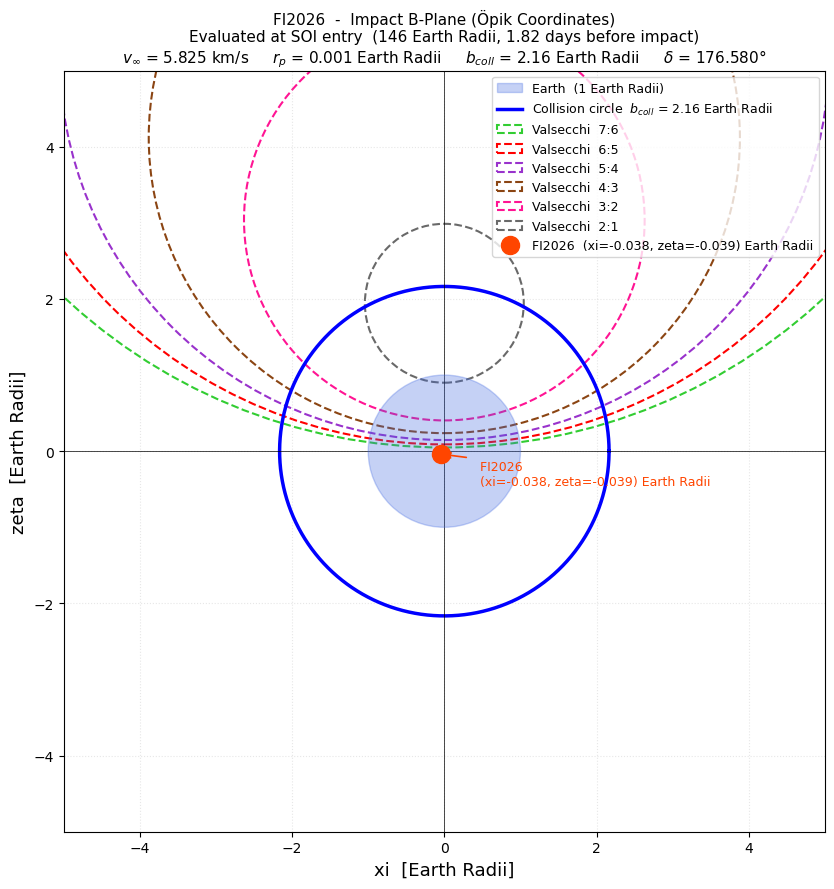

In [34]:
# SOI entry point
t_s  = np.linspace(t_impact - 10, t_impact, 100000)
d_s  = np.array([geocentric_dist(t) for t in t_s])
idx  = np.where((d_s[:-1] >= R_SOI) & (d_s[1:] < R_SOI))[0]
t_soi = brentq(lambda t: geocentric_dist(t) - R_SOI,
               t_s[idx[0]], t_s[idx[0]+1], xtol=1e-10)

# States at SOI entry
rE_au,vE_au,rA_au,vA_au = get_states_au(t_soi)
rE = rE_au*au2km;  vE = vE_au*au2km_s
rA = rA_au*au2km;  vA = vA_au*au2km_s

rho   = rA - rE;  u = vA - vE;  rho_n = np.linalg.norm(rho)
v_inf = np.sqrt(u@u - 2*mu_earth/rho_n)

u_inf_minus = v_inf*(u/np.linalg.norm(u))
h_vec       = np.cross(rho, u);  h = np.linalg.norm(h_vec);  h_hat = h_vec/h
e_hyp       = np.sqrt(1 + (h*v_inf)**2/mu_earth**2)
delta       = 2*np.arcsin(1./e_hyp)
u_inf_plus  = vecRot3D(u_inf_minus, h_hat, delta)
r_p         = h**2/(mu_earth*(1 + e_hyp))

s_hat    = u_inf_minus/v_inf
xi_hat   = np.cross(vE, s_hat)/np.linalg.norm(np.cross(vE, s_hat))
zeta_hat = np.cross(-s_hat, xi_hat)

b_vec  = np.cross(s_hat, h_vec)/v_inf
xi0    = np.dot(b_vec, xi_hat)
zeta0  = np.dot(b_vec, zeta_hat)
b0     = np.linalg.norm(b_vec)
b_coll = R_earth*np.sqrt(1. + 2*mu_earth/(R_earth*v_inf**2))
val_circles = valsecchi_circles(v_inf, np.linalg.norm(vE))

print(f"\nTask 2 - B-plane (evaluated at SOI entry, {geocentric_dist(t_soi)/R_earth:.0f} Earth Radii)")

print(f"  Hyperbolic excess velocity (v_inf)        = {v_inf:.4f} km/s")
print(f"  Hyperbolic eccentricity                   = {e_hyp:.4f}")
print(f"  Periapsis distance                        = {r_p:.1f} km  ({r_p/R_earth:.4f} Earth Radii)")
print(f"  Gravitational turning angle (delta)       = {np.degrees(delta):.4f}°")

print(f"  B-plane xi coordinate                 = {xi0/R_earth:.4f} Earth Radii")
print(f"  B-plane zeta coordinate               = {zeta0/R_earth:.4f} Earth Radii")

print(f"  Impact parameter magnitude |b|            = {b0/R_earth:.4f} Earth Radii")
print(f"  Impact cross-section radius (b_coll)      = {b_coll/R_earth:.4f} Earth Radii")
# -- Plot -----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 9))
th = np.linspace(0, TWOPI, 500)

# Earth disk
ax.add_patch(patches.Circle((0, 0), 1.0, color='royalblue',
             alpha=0.3, zorder=3, label='Earth  (1 Earth Radii)'))

# Collision circle
ax.plot(b_coll/R_earth * np.cos(th), b_coll/R_earth * np.sin(th),
        'b-', lw=2.5,
        label=f'Collision circle  $b_{{coll}}$ = {b_coll/R_earth:.2f} Earth Radii')

# Valsecchi circles
colors = ['limegreen','red','darkorchid','saddlebrown','deeppink','dimgray']
for (p, q, D, Rv), col in zip(val_circles, colors):
    if abs(Rv)/R_earth < 30 and abs(D)/R_earth < 30:
        ax.add_patch(patches.Circle((0, D/R_earth), Rv/R_earth,
                     fill=False, color=col, lw=1.5, ls='--',
                     label=f'Valsecchi  {p}:{q}'))

# Encounter point
ax.plot(xi/R_earth, zeta/R_earth, 'o', color='orangered',
        ms=13, zorder=6,
        label=f'FI2026  (xi={xi/R_earth:.3f}, zeta={zeta/R_earth:.3f}) Earth Radii')
ax.annotate(f'  FI2026\n  (xi={xi/R_earth:.3f}, zeta={zeta/R_earth:.3f}) Earth Radii',
            xy=(xi/R_earth, zeta/R_earth),
            xytext=(xi/R_earth + 0.4, zeta/R_earth - 0.4),
            fontsize=9, color='orangered',
            arrowprops=dict(arrowstyle='->', color='orangered', lw=1.2))

ax.set_xlabel('xi  [Earth Radii]', fontsize=13)
ax.set_ylabel('zeta  [Earth Radii]', fontsize=13)
ax.set_title(
    'FI2026  -  Impact B-Plane (Öpik Coordinates)\n'
    f'Evaluated at SOI entry  ({geocentric_dist(t_soi)/R_earth:.0f} Earth Radii, '
    f'{t_impact - t_soi:.2f} days before impact)\n'
    f'$v_\\infty$ = {v_inf:.3f} km/s     '
    f'$r_p$ = {r_p/R_earth:.3f} Earth Radii     '
    f'$b_{{coll}}$ = {b_coll/R_earth:.2f} Earth Radii     '
    f'$\\delta$ = {np.degrees(delta):.3f}°',
    fontsize=11)

ax.set_aspect('equal')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3, ls=':')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)

lim = max(b_coll/R_earth * 1.8,
          abs(xi/R_earth) * 1.5,
          abs(zeta/R_earth) * 1.5, 5)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

plt.tight_layout()

# Task 3 #

In [35]:
def gauss_averaged_rates(a, e, i, w, mu, FR=0., FS=0., FW=0., N=3000):
    """
    Orbit-averaged Gauss Planetary Equation rates per unit acceleration.
    Integration over true anomaly using trapezoidal rule.
    Returns [<da/dt>, <de/dt>, <di/dt>, <dOm/dt>, <dw/dt>] per unit F.
    """
    p = a*(1 - e**2);  h = np.sqrt(mu*p);  T = TWOPI*np.sqrt(a**3/mu)
    f_arr  = np.linspace(0, TWOPI, N+1)
    integrand = np.zeros((N+1, 5))

    for k, f in enumerate(f_arr):
        cf = np.cos(f);  sf = np.sin(f)
        r  = p/(1 + e*cf)
        wt = r**2/h/T    # orbit-average weight: dt/df / T

        da  = (2*a**2/h)*(e*sf*FR + (p/r)*FS)
        de  = (1/h)*(p*sf*FR + ((p+r)*cf + r*e)*FS)
        di  = (r*np.cos(f+w)/h)*FW
        dOm = (r*np.sin(f+w)/(h*np.sin(max(abs(i), 1e-10))))*FW \
              if abs(np.sin(i)) > 1e-10 else 0.
        dw  = (1/(h*max(e, 1e-10)))*(-p*cf*FR + (p+r)*sf*FS) - dOm*np.cos(i)

        integrand[k] = np.array([da, de, di, dOm, dw])*wt

    df = f_arr[1] - f_arr[0]
    return np.trapz(integrand, dx=df, axis=0)

# Finite-difference Jacobian: d(xi,zeta)/d(a,e,i,Om,w)
eps = dict(a=1e-6, e=1e-7, ang=1e-7)

def bvec(da=0, de=0, di=0, dOm=0, dw=0):
    xi,zeta,b,_ = compute_bplane(a2+da, e2+de, i2+di, O2+dOm, w2+dw, M2_0)
    return np.array([xi, zeta])

print("\n  Computing b-plane Jacobian (finite differences)...")
J = np.column_stack([
    (bvec(da=+eps['a'])  - bvec(da=-eps['a']))  / (2*eps['a']),    # d/da
    (bvec(de=+eps['e'])  - bvec(de=-eps['e']))  / (2*eps['e']),    # d/de
    (bvec(di=+eps['ang'])- bvec(di=-eps['ang']))/ (2*eps['ang']),  # d/di
    (bvec(dOm=+eps['ang'])-bvec(dOm=-eps['ang']))/(2*eps['ang']), # d/dOm
    (bvec(dw=+eps['ang'])- bvec(dw=-eps['ang']))/ (2*eps['ang']),  # d/dw
])  # shape (2, 5): rows = [xi, zeta], cols = [a, e, i, Om, w]

# For continuous thrust F over t_impact days:
#   dOE = <dOE/dt>/F * F * t_impact = rates * t_impact * F
#   dV  = F * t_impact  =>  dOE = rates * dV_total
# b-plane shift per unit dV [au/day]:
#   d(xi,zeta)/dV = J @ rates(direction) * t_impact

b_target = 4.0*R_earth   # km

print(f"\n{'='*60}")
print(f"Task 3 - Slow-push deflection (continuous thrust, {t_impact:.1f} day lead time)")
print(f"  Target: |b| >= {b_target/R_earth:.0f} Earth Radii = {b_target:.1f} km")
print(f"  Baseline:      {b0/R_earth:.4f} Earth Radii")
print(f"{'='*60}")

deflected_points = {}
directions = [
    ('Radial (R)',     1., 0., 0.),
    ('Transverse (S)', 0., 1., 0.),
    ('Normal (W)',     0., 0., 1.),
]

for name, FR, FS, FW in directions:
    rates        = gauss_averaged_rates(a2, e2, i2, w2, mu_au, FR, FS, FW)
    db_dV        = J @ (rates * t_impact)   # [km / (au/day)]

    # Solve quadratic: |b0_vec + db_dV * dV|^2 = b_target^2
    b0_vec_2d = np.array([xi0, zeta0])
    A = db_dV @ db_dV
    B = 2*(b0_vec_2d @ db_dV)
    C = b0_vec_2d @ b0_vec_2d - b_target**2

    disc = B**2 - 4*A*C
    dV_candidates = []
    if disc >= 0 and A > 1e-30:
        for sign in [+1, -1]:
            d = (-B + sign*np.sqrt(disc))/(2*A)
            if d > 0:
                dV_candidates.append(d)
    dV_au_day = min(dV_candidates) if dV_candidates else np.inf

    dV_km_s   = dV_au_day * au2km_s
    dV_mm_s   = dV_km_s * 1e6
    accel_ms2 = (dV_au_day/t_impact) * au2km*1e3/day2s**2

    xi_new   = xi0   + db_dV[0]*dV_au_day
    zeta_new = zeta0 + db_dV[1]*dV_au_day
    b_new    = np.sqrt(xi_new**2 + zeta_new**2)

    deflected_points[name] = (xi_new, zeta_new, dV_mm_s)

    print(f"\n  {name}")
    print(f"    dV required    = {dV_mm_s:.4f} mm/s  ({dV_km_s:.2e} km/s)")
    print(f"    Acceleration   = {accel_ms2:.4e} m/s²")
    print(f"    New position   = ({xi_new/R_earth:.3f}, {zeta_new/R_earth:.3f}) Earth Radii")
    print(f"    New |b|        = {b_new/R_earth:.4f} Earth Radii  [Success]" if b_new >= b_target*0.999
          else f"    New |b|        = {b_new/R_earth:.4f} Earth Radii  [Failed]")


  Computing b-plane Jacobian (finite differences)...

Task 3 - Slow-push deflection (continuous thrust, 360.0 day lead time)
  Target: |b| >= 4 Earth Radii = 25512.5 km
  Baseline:      0.0550 Earth Radii

  Radial (R)
    dV required    = 15.2623 mm/s  (1.53e-05 km/s)
    Acceleration   = 4.9069e-10 m/s²
    New position   = (0.134, -3.998) Earth Radii
    New |b|        = 4.0000 Earth Radii  [Success]

  Transverse (S)
    dV required    = 0.8469 mm/s  (8.47e-07 km/s)
    Acceleration   = 2.7228e-11 m/s²
    New position   = (0.129, 3.998) Earth Radii
    New |b|        = 4.0000 Earth Radii  [Success]

  Normal (W)
    dV required    = 65.3868 mm/s  (6.54e-05 km/s)
    Acceleration   = 2.1022e-09 m/s²
    New position   = (3.993, -0.234) Earth Radii
    New |b|        = 4.0000 Earth Radii  [Success]


# Task 4 #


  Computing extended b-plane Jacobian including dM...

Task 4 - Kinetic Impact deflection
  Target: |b| >= 4 Earth Radii  |  Baseline: 0.0550 Earth Radii

  Radial (R)
    Optimal kick time = 10.0 days  (350.0 days before impact)
    dV required       = 419.5390 mm/s  (4.20e-04 km/s)
    New position      = (-0.033, -4.000) Earth Radii
    New |b|           = 4.0000 Earth Radii  [Success]

  Transverse (S)
    Optimal kick time = 85.0 days  (275.0 days before impact)
    dV required       = 140.7222 mm/s  (1.41e-04 km/s)
    New position      = (0.020, 4.000) Earth Radii
    New |b|           = 4.0000 Earth Radii  [Success]

  Normal (W)
    Optimal kick time = 255.0 days  (105.0 days before impact)
    dV required       = 4721.4150 mm/s  (4.72e-03 km/s)
    New position      = (3.993, -0.234) Earth Radii
    New |b|           = 4.0000 Earth Radii  [Success]


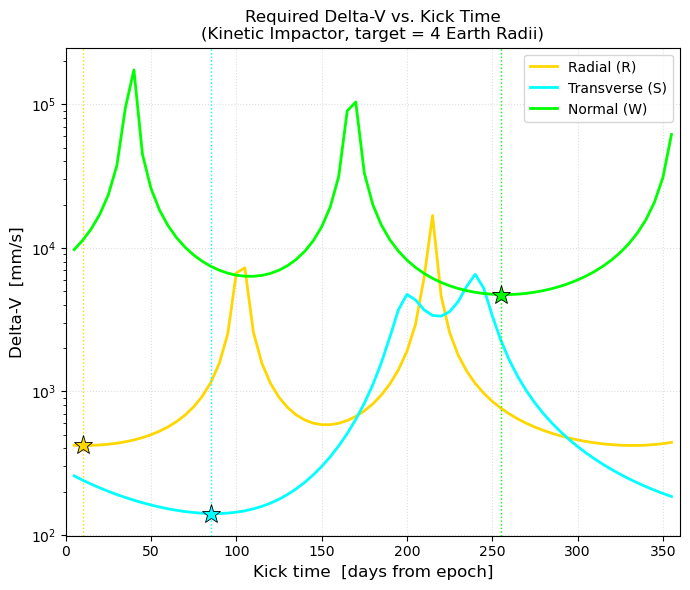

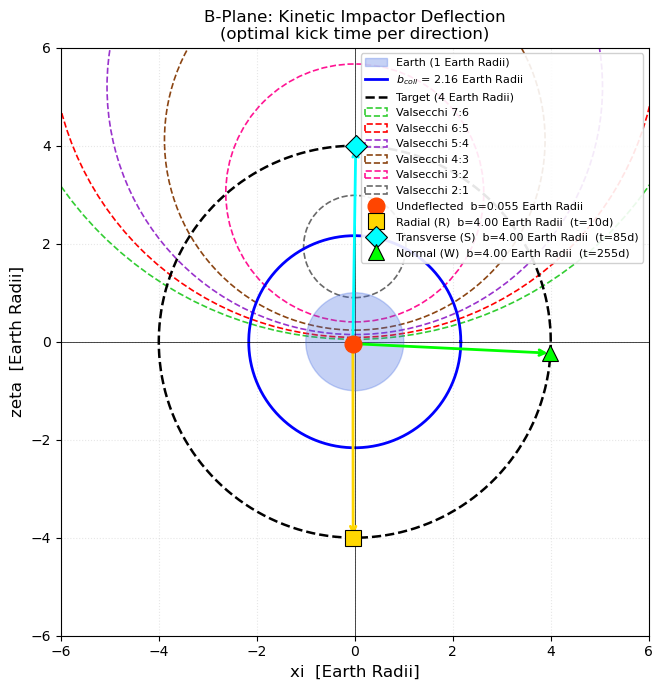

In [41]:


def gauss_instantaneous(a, e, i, Om, w, M_at_kick, mu, FR=0., FS=0., FW=0.):
    """
    Instantaneous Gauss Planetary Equation deltas per unit delta-V
    applied at the orbital position given by M_at_kick.
    Returns [da, de, di, dOm, dw, dM] per unit dV.
    """
    E  = solve_kepler(M_at_kick, e)
    f  = 2*atan2(sqrt(1+e)*np.sin(E/2), sqrt(1-e)*np.cos(E/2))
    cf = np.cos(f);  sf = np.sin(f)
    r  = a*(1 - e*np.cos(E))
    p  = a*(1 - e**2)
    h  = np.sqrt(mu*p)
    n  = np.sqrt(mu/a**3)
    b_orb = a*np.sqrt(1 - e**2)   # semi-minor axis

    da  = (2*a**2/h)*(e*sf*FR + (p/r)*FS)
    de  = (1/h)*(p*sf*FR + ((p+r)*cf + r*e)*FS)
    di  = (r*np.cos(f+w)/h)*FW
    dOm = (r*np.sin(f+w)/(h*np.sin(max(abs(i), 1e-10))))*FW \
          if abs(np.sin(i)) > 1e-10 else 0.
    dw  = (1/(h*max(e, 1e-10)))*(-p*cf*FR + (p+r)*sf*FS) - dOm*np.cos(i)
    dM  = -(b_orb/(a*max(e,1e-10)*h))*((p*cf - 2*r*e)*FR - (p+r)*sf*FS)

    return np.array([da, de, di, dOm, dw, dM])

# Jacobian extended to include dM effect on b-plane
# dM shifts the mean anomaly at epoch, which shifts where the asteroid is
# at the SOI crossing -> affects xi, zeta
eps = dict(a=1e-6, e=1e-7, ang=1e-7, M=1e-7)

def bvec_full(da=0, de=0, di=0, dOm=0, dw=0, dM=0):
    xi,zeta,_,_ = compute_bplane(a2+da, e2+de, i2+di,
                                  O2+dOm, w2+dw, M2_0+dM)
    return np.array([xi, zeta])

print("\n  Computing extended b-plane Jacobian including dM...")
J6 = np.column_stack([
    (bvec_full(da=+eps['a'])   - bvec_full(da=-eps['a']))   / (2*eps['a']),
    (bvec_full(de=+eps['e'])   - bvec_full(de=-eps['e']))   / (2*eps['e']),
    (bvec_full(di=+eps['ang']) - bvec_full(di=-eps['ang'])) / (2*eps['ang']),
    (bvec_full(dOm=+eps['ang'])- bvec_full(dOm=-eps['ang']))/ (2*eps['ang']),
    (bvec_full(dw=+eps['ang']) - bvec_full(dw=-eps['ang'])) / (2*eps['ang']),
    (bvec_full(dM=+eps['M'])   - bvec_full(dM=-eps['M']))   / (2*eps['M']),
])  # shape (2, 6)

# Scan kick times: every 5 days from t=5 to t_impact-1
t_ki_arr   = np.arange(5, t_impact - 1, 5)
b0_vec_2d  = np.array([xi0, zeta0])
b_target   = 4.0*R_earth

print(f"\n{'='*60}")
print(f"Task 4 - Kinetic Impact deflection")
print(f"  Target: |b| >= {b_target/R_earth:.0f} Earth Radii  |  Baseline: {b0/R_earth:.4f} Earth Radii")
print(f"{'='*60}")

directions = [
    ('Radial (R)',     1., 0., 0.),
    ('Transverse (S)', 0., 1., 0.),
    ('Normal (W)',     0., 0., 1.),
]

ki_results   = {name: [] for name,*_ in directions}  # (t_ki, dV_mm_s) per direction
ki_best      = {}

for name, FR, FS, FW in directions:
    dV_list = []
    for t_ki in t_ki_arr:
        # Mean anomaly of FI2026 at kick time
        M_ki = (M2_0 + n2*t_ki) % TWOPI

        # Instantaneous element deltas per unit dV at this kick point
        dOE6 = gauss_instantaneous(a2, e2, i2, O2, w2, M_ki, mu_au, FR, FS, FW)

        # b-plane shift per unit dV [au/day]
        db_dV = J6 @ dOE6   # shape (2,)

        # Solve quadratic for required dV
        A = db_dV @ db_dV
        B = 2*(b0_vec_2d @ db_dV)
        C = b0_vec_2d @ b0_vec_2d - b_target**2
        disc = B**2 - 4*A*C
        if disc < 0 or A < 1e-30:
            dV_list.append(np.inf)
            continue
        candidates = [(-B + s*np.sqrt(disc))/(2*A) for s in [+1,-1] if (-B + s*np.sqrt(disc))/(2*A) > 0]
        dV_list.append(min(candidates) if candidates else np.inf)

    dV_arr    = np.array(dV_list) * au2km_s * 1e6   # convert to mm/s
    ki_results[name] = (t_ki_arr, dV_arr)

    finite    = np.isfinite(dV_arr)
    if finite.any():
        idx_best  = np.argmin(dV_arr[finite])
        t_best    = t_ki_arr[finite][idx_best]
        dV_best   = dV_arr[finite][idx_best]

        # Recompute new b position at best kick time
        M_ki    = (M2_0 + n2*t_best) % TWOPI
        dOE6    = gauss_instantaneous(a2, e2, i2, O2, w2, M_ki, mu_au, FR, FS, FW)
        db_dV   = J6 @ dOE6
        dV_au   = dV_best / (au2km_s*1e6)
        xi_new  = xi0   + db_dV[0]*dV_au
        zeta_new= zeta0 + db_dV[1]*dV_au
        b_new   = np.sqrt(xi_new**2 + zeta_new**2)

        ki_best[name] = (t_best, dV_best, xi_new, zeta_new, b_new)

        print(f"\n  {name}")
        print(f"    Optimal kick time = {t_best:.1f} days  "
              f"({t_impact - t_best:.1f} days before impact)")
        print(f"    dV required       = {dV_best:.4f} mm/s  ({dV_best/1e6:.2e} km/s)")
        print(f"    New position      = ({xi_new/R_earth:.3f}, {zeta_new/R_earth:.3f}) Earth Radii")
        print(f"    New |b|           = {b_new/R_earth:.4f} Earth Radii  "
              + ("[Success]" if b_new >= b_target*0.999 else "[Failed]"))
    else:
        print(f"\n  {name}:  no valid solution found")



# ---- Plot 1: dV vs kick time ---------------------------------------
plt.figure(figsize=(7,6))
ax = plt.gca()

plot_colors = {'Radial (R)':'gold', 'Transverse (S)':'cyan', 'Normal (W)':'lime'}

for name, FR, FS, FW in directions:
    t_arr, dV_arr = ki_results[name]
    mask = np.isfinite(dV_arr) & (dV_arr < 1e6)

    ax.semilogy(t_arr[mask], dV_arr[mask], lw=2,
                color=plot_colors[name], label=name)

    if name in ki_best:
        t_b, dV_b, *_ = ki_best[name]
        ax.axvline(t_b, color=plot_colors[name], lw=1, ls=':')
        ax.plot(t_b, dV_b, '*', color=plot_colors[name],
                ms=14, markeredgecolor='k', markeredgewidth=0.6)

ax.set_xlabel('Kick time  [days from epoch]', fontsize=12)
ax.set_ylabel('Delta-V  [mm/s]', fontsize=12)
ax.set_title('Required Delta-V vs. Kick Time\n(Kinetic Impactor, target = 4 Earth Radii)', fontsize=12)

ax.legend(fontsize=10)
ax.grid(True, alpha=0.4, ls=':')
ax.set_xlim(0, t_impact)

plt.tight_layout()
plt.show()

# ---- Plot 2: B-plane deflection ------------------------------------
plt.figure(figsize=(7,7))
ax2 = plt.gca()

th = np.linspace(0, TWOPI, 500)

ax2.add_patch(patches.Circle((0,0), 1., color='royalblue',
                             alpha=0.3, zorder=3,
                             label='Earth (1 Earth Radii)'))

ax2.plot(b_coll/R_earth*np.cos(th), b_coll/R_earth*np.sin(th),
         'b-', lw=2, label=f'$b_{{coll}}$ = {b_coll/R_earth:.2f} Earth Radii')

ax2.plot(4*np.cos(th), 4*np.sin(th),
         'k--', lw=1.8, label='Target (4 Earth Radii)')

for (p,q,D,Rv), col in zip(val_circles, vc_colors):
    if abs(Rv)/R_earth < 8 and abs(D)/R_earth < 8:
        ax2.add_patch(patches.Circle((0,D/R_earth), Rv/R_earth,
                      fill=False, color=col, lw=1.2, ls='--',
                      label=f'Valsecchi {p}:{q}'))

ax2.plot(xi0/R_earth, zeta0/R_earth, 'o',
         color='orangered', ms=12, zorder=6,
         label=f'Undeflected  b={b0/R_earth:.3f} Earth Radii')

mrk_map = {'Radial (R)':'s', 'Transverse (S)':'D', 'Normal (W)':'^'}

for name, FR, FS, FW in directions:
    if name in ki_best:
        t_b, dV_b, xi_d, zeta_d, b_d = ki_best[name]

        col = plot_colors[name]
        mrk = mrk_map[name]

        ax2.annotate('',
                     xy=(xi_d/R_earth, zeta_d/R_earth),
                     xytext=(xi0/R_earth, zeta0/R_earth),
                     arrowprops=dict(arrowstyle='->', color=col, lw=2.))

        ax2.plot(xi_d/R_earth, zeta_d/R_earth,
                 mrk, color=col, ms=11,
                 zorder=7,
                 markeredgecolor='k',
                 markeredgewidth=0.8,
                 label=f'{name}  b={b_d/R_earth:.2f} Earth Radii  (t={t_b:.0f}d)')

ax2.set_xlabel('xi  [Earth Radii]', fontsize=12)
ax2.set_ylabel('zeta  [Earth Radii]', fontsize=12)

ax2.set_title('B-Plane: Kinetic Impactor Deflection\n(optimal kick time per direction)',
              fontsize=12)

ax2.set_aspect('equal')
ax2.legend(fontsize=8, loc='upper right', framealpha=0.9)

ax2.grid(True, alpha=0.3, ls=':')
ax2.axhline(0, color='k', lw=0.5)
ax2.axvline(0, color='k', lw=0.5)

lim = 6.0
ax2.set_xlim(-lim, lim)
ax2.set_ylim(-lim, lim)

plt.tight_layout()
plt.show()

# Task 5 #

In [37]:
from scipy.optimize import minimize

# Cardinal b-plane sensitivity vectors [km per (au/day) of Delta-V]
rR = gauss_averaged_rates(a2, e2, i2, w2, mu_au, 1., 0., 0.)
rS = gauss_averaged_rates(a2, e2, i2, w2, mu_au, 0., 1., 0.)
rW = gauss_averaged_rates(a2, e2, i2, w2, mu_au, 0., 0., 1.)
gR = J @ (rR * t_impact)
gS = J @ (rS * t_impact)
gW = J @ (rW * t_impact)

b0_2d = np.array([xi0, zeta0])

def dV_required(FR, FS, FW):
    """Delta-V [au/day] to reach b_target for unit thrust direction (FR, FS, FW)."""
    nrm = np.sqrt(FR**2 + FS**2 + FW**2)
    if nrm < 1e-15: return np.inf
    db  = (FR*gR + FS*gS + FW*gW) / nrm
    A   = db @ db
    B   = 2*(b0_2d @ db)
    C   = b0_2d @ b0_2d - b_target**2
    disc = B**2 - 4*A*C
    if disc < 0 or A < 1e-30: return np.inf
    cands = [(-B + s*np.sqrt(disc))/(2*A) for s in [+1,-1]
             if (-B + s*np.sqrt(disc))/(2*A) > 0]
    return min(cands) if cands else np.inf

# Coarse grid search (cheap - linear in (FR,FS,FW), no GPE calls needed)
N_grid = 200
best_dV = np.inf;  best_th = 0.;  best_ph = 0.
for th in np.linspace(0, TWOPI, N_grid, endpoint=False):
    for ph in np.linspace(-np.pi/2, np.pi/2, N_grid):
        dv = dV_required(np.cos(ph)*np.cos(th), np.cos(ph)*np.sin(th), np.sin(ph))
        if dv < best_dV:
            best_dV = dv;  best_th = th;  best_ph = ph

# Refine with Nelder-Mead
def obj5(x):
    return dV_required(np.cos(x[1])*np.cos(x[0]), np.cos(x[1])*np.sin(x[0]), np.sin(x[1]))

res5 = minimize(obj5, x0=[best_th, best_ph], method='Nelder-Mead',
                options={'xatol':1e-9, 'fatol':1e-12, 'maxiter':20000})
opt_theta, opt_phi = res5.x
FR_opt = np.cos(opt_phi)*np.cos(opt_theta)
FS_opt = np.cos(opt_phi)*np.sin(opt_theta)
FW_opt = np.sin(opt_phi)

opt_dV_au_day = res5.fun
opt_dV_km_s   = opt_dV_au_day * au2km_s
opt_dV_mm_s   = opt_dV_km_s * 1e6
opt_accel     = (opt_dV_au_day/t_impact) * au2km*1e3/day2s**2

db_dV_opt = FR_opt*gR + FS_opt*gS + FW_opt*gW
xi_opt    = xi0   + db_dV_opt[0]*opt_dV_au_day
zeta_opt  = zeta0 + db_dV_opt[1]*opt_dV_au_day
b_opt     = np.sqrt(xi_opt**2 + zeta_opt**2)

print(f"\n{'='*60}")
print(f"Task 5 - Optimal thrust direction")
print(f"{'='*60}")
print(f"  F_R = {FR_opt:+.6f}  (radial)")
print(f"  F_S = {FS_opt:+.6f}  (transverse)")
print(f"  F_W = {FW_opt:+.6f}  (normal)")
print(f"  Delta-V required    = {opt_dV_mm_s:.4f} mm/s  ({opt_dV_km_s:.2e} km/s)")
print(f"  Acceleration   = {opt_accel:.4e} m/s²")
print(f"  New b-plane    = ({xi_opt/R_earth:.3f}, {zeta_opt/R_earth:.3f}) Earth Radii")
print(f"  New |b|        = {b_opt/R_earth:.4f} Earth Radii  [Success]")
print(f"\n  Improvement over best single-axis (S): "
      f"{deflected_points['Transverse (S)'][2]/opt_dV_mm_s:.4f}×")


Task 5 - Optimal thrust direction
  F_R = +0.054094  (radial)
  F_S = -0.998536  (transverse)
  F_W = -0.000028  (normal)
  Delta-V required    = 0.8285 mm/s  (8.29e-07 km/s)
  Acceleration   = 2.6638e-11 m/s²
  New b-plane    = (-0.201, -3.995) Earth Radii
  New |b|        = 4.0000 Earth Radii  [Success]

  Improvement over best single-axis (S): 1.0222×


# Task 6 #


Task 6 - Valsecchi circle avoidance check
  Checking all deflection scenarios against resonance circles...

  Radial (R):  (0.134, -3.998) Earth Radii
    [Success]  Clears all resonance circles

  Transverse (S):  (0.129, 3.998) Earth Radii
    [Caution]  INSIDE Valsecchi 7:6  (dist to centre = 3.368 Earth Radii < R = 7.314 Earth Radii)
    [Caution]  INSIDE Valsecchi 6:5  (dist to centre = 2.289 Earth Radii < R = 6.194 Earth Radii)
    [Caution]  INSIDE Valsecchi 5:4  (dist to centre = 1.212 Earth Radii < R = 5.056 Earth Radii)
    [Caution]  INSIDE Valsecchi 4:3  (dist to centre = 0.178 Earth Radii < R = 3.884 Earth Radii)
    [Caution]  INSIDE Valsecchi 3:2  (dist to centre = 0.970 Earth Radii < R = 2.632 Earth Radii)

  Normal (W):  (3.993, -0.234) Earth Radii
    [Success]  Clears all resonance circles

  Optimal:  (-0.201, -3.995) Earth Radii
    [Success]  Clears all resonance circles

  Valsecchi circle summary (v_inf = 5.825 km/s):
    7:6  centre zeta=7.363 Earth Radii,  ra

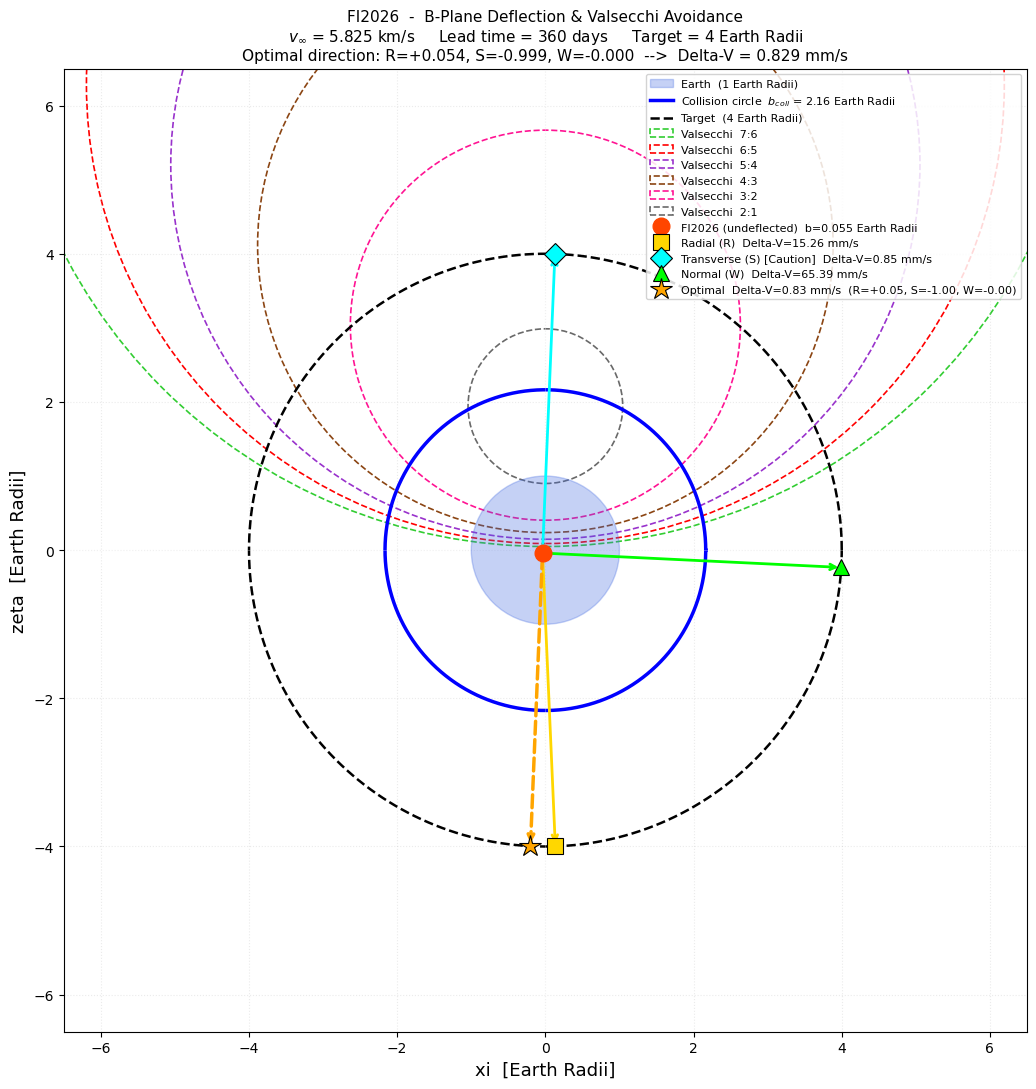

In [43]:
print(f"\n{'='*60}")
print(f"Task 6 - Valsecchi circle avoidance check")
print(f"{'='*60}")
print(f"  Checking all deflection scenarios against resonance circles...\n")

def check_valsecchi_avoidance(xi_new, zeta_new, label):
    """Check if (xi_new, zeta_new) lies inside any Valsecchi circle."""
    print(f"  {label}:  ({xi_new/R_earth:.3f}, {zeta_new/R_earth:.3f}) Earth Radii")
    any_inside = False
    for (p, q, D, Rv) in val_circles:
        # Distance from new point to circle centre (0, D) in b-plane
        dist_to_centre = np.sqrt(xi_new**2 + (zeta_new - D)**2)
        inside = dist_to_centre < Rv
        if inside:
            print(f"    [Caution]  INSIDE Valsecchi {p}:{q}  "
                  f"(dist to centre = {dist_to_centre/R_earth:.3f} Earth Radii < R = {Rv/R_earth:.3f} Earth Radii)")
            any_inside = True
    if not any_inside:
        print(f"    [Success]  Clears all resonance circles")
    return not any_inside

# Check all scenarios
scenarios = {
    'Radial (R)':     deflected_points['Radial (R)'][:2],
    'Transverse (S)': deflected_points['Transverse (S)'][:2],
    'Normal (W)':     deflected_points['Normal (W)'][:2],
    'Optimal':        (xi_opt, zeta_opt),
}
avoidance = {}
for label, (xi_d, zeta_d) in scenarios.items():
    avoidance[label] = check_valsecchi_avoidance(xi_d, zeta_d, label)
    print()

# Also print the Valsecchi circle geometry for reference
print(f"  Valsecchi circle summary (v_inf = {v_inf:.3f} km/s):")
for (p, q, D, Rv) in val_circles:
    print(f"    {p}:{q}  centre zeta={D/R_earth:.3f} Earth Radii,  radius={Rv/R_earth:.3f} Earth Radii,  "
          f"inner edge zeta={(D-Rv)/R_earth:.3f} Earth Radii")

# -- Combined plot: Tasks 2, 3, 5, 6 ------------------------------------------
fig, ax = plt.subplots(figsize=(11, 11))
th = np.linspace(0, TWOPI, 500)

# Earth disk
ax.add_patch(patches.Circle((0,0), 1.0, color='royalblue',
             alpha=0.3, zorder=3, label='Earth  (1 Earth Radii)'))

# Collision circle
ax.plot(b_coll/R_earth*np.cos(th), b_coll/R_earth*np.sin(th),
        'b-', lw=2.5, label=f'Collision circle  $b_{{coll}}$ = {b_coll/R_earth:.2f} Earth Radii')

# Target circle (4 Earth Radii)
ax.plot(4*np.cos(th), 4*np.sin(th),
        'k--', lw=1.8, label='Target  (4 Earth Radii)')

# Valsecchi circles
vc_colors = ['limegreen','red','darkorchid','saddlebrown','deeppink','dimgray']
for (p,q,D,Rv), col in zip(val_circles, vc_colors):
    if abs(Rv)/R_earth < 30 and abs(D)/R_earth < 30:
        ax.add_patch(patches.Circle((0, D/R_earth), Rv/R_earth,
                     fill=False, color=col, lw=1.2, ls='--',
                     label=f'Valsecchi  {p}:{q}'))

# Baseline
ax.plot(xi0/R_earth, zeta0/R_earth, 'o', color='orangered',
        ms=12, zorder=6, label=f'FI2026 (undeflected)  b={b0/R_earth:.3f} Earth Radii')

# Single-axis deflection arrows
def_colors  = {'Radial (R)':'gold', 'Transverse (S)':'cyan', 'Normal (W)':'lime'}
def_markers = {'Radial (R)':'s',    'Transverse (S)':'D',    'Normal (W)':'^'}
for name,(xi_d,zeta_d,dV_d) in deflected_points.items():
    col = def_colors[name];  mrk = def_markers[name]
    ax.annotate('', xy=(xi_d/R_earth, zeta_d/R_earth),
                xytext=(xi0/R_earth, zeta0/R_earth),
                arrowprops=dict(arrowstyle='->', color=col, lw=2.0))
    safe_mark = '' if avoidance[name] else ' [Caution]'
    ax.plot(xi_d/R_earth, zeta_d/R_earth, mrk, color=col, ms=11,
            zorder=7, markeredgecolor='k', markeredgewidth=0.8,
            label=f'{name}{safe_mark}  Delta-V={dV_d:.2f} mm/s')

# Optimal direction
ax.annotate('', xy=(xi_opt/R_earth, zeta_opt/R_earth),
            xytext=(xi0/R_earth, zeta0/R_earth),
            arrowprops=dict(arrowstyle='->', color='orange', lw=2.5,
                            linestyle='dashed'))
safe_mark = '' if avoidance['Optimal'] else ' [Caution]'
ax.plot(xi_opt/R_earth, zeta_opt/R_earth, '*', color='orange', ms=16,
        zorder=8, markeredgecolor='k', markeredgewidth=0.8,
        label=f'Optimal{safe_mark}  Delta-V={opt_dV_mm_s:.2f} mm/s  '
              f'(R={FR_opt:+.2f}, S={FS_opt:+.2f}, W={FW_opt:+.2f})')

ax.set_xlabel('xi  [Earth Radii]', fontsize=13)
ax.set_ylabel('zeta  [Earth Radii]', fontsize=13)
ax.set_title(
    'FI2026  -  B-Plane Deflection & Valsecchi Avoidance\n'
    f'$v_\\infty$ = {v_inf:.3f} km/s     Lead time = {t_impact:.0f} days     Target = 4 Earth Radii\n'
    f'Optimal direction: R={FR_opt:+.3f}, S={FS_opt:+.3f}, W={FW_opt:+.3f}  '
    f'-->  Delta-V = {opt_dV_mm_s:.3f} mm/s',
    fontsize=11)

ax.set_aspect('equal')
ax.legend(fontsize=8, loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.25, ls=':')
ax.axhline(0, color='w', lw=0.4, alpha=0.5)
ax.axvline(0, color='w', lw=0.4, alpha=0.5)

lim = 6.5
ax.set_xlim(-lim, lim);  ax.set_ylim(-lim, lim)
plt.tight_layout()